In [2]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Setting visual styling
sns.set_theme(style = "whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"

#Connect simulated_transactions from 02_policy_simulation
conn = sqlite3.connect("market_data.db")
df_sim = pd.read_sql_query("SELECT * FROM simulated_transactions;", conn)
conn.close()

print("Successfully loaded {len(df_sim)} records")
df_sim.head()

Successfully loaded {len(df_sim)} records


,transaction_id,quarter_date,region_id,firm_id,baseline_units,unit_cost,baseline_price,baseline_revenue,baseline_profit,max_allowed_price,policy_price,pct_change_price,pct_change_units,policy_units,policy_revenue,policy_profit
0,1,2024-Q1,North,Firm A,93,10.77,13.90,1292.70,291.09,13.4625,13.4625,-0.031475,0.023606,95.195369,1281.567651,256.313530
1,2,2024-Q1,North,Firm B,188,10.06,13.27,2494.76,603.48,12.5750,12.5750,-0.052374,0.039280,195.384702,2456.962632,491.392526
2,3,2024-Q1,North,Firm C,338,9.87,12.71,4295.98,959.92,12.3375,12.3375,-0.029308,0.021981,345.429485,4261.736267,852.347253
3,4,2024-Q1,North,Firm D,376,9.88,12.76,4797.76,1082.88,12.3500,12.3500,-0.032132,0.024099,385.061129,4755.504937,951.100987
4,5,2024-Q1,North,Firm E,404,8.87,11.25,4545.00,961.52,11.0875,11.0875,-0.014444,0.010833,408.376667,4527.876292,905.575258


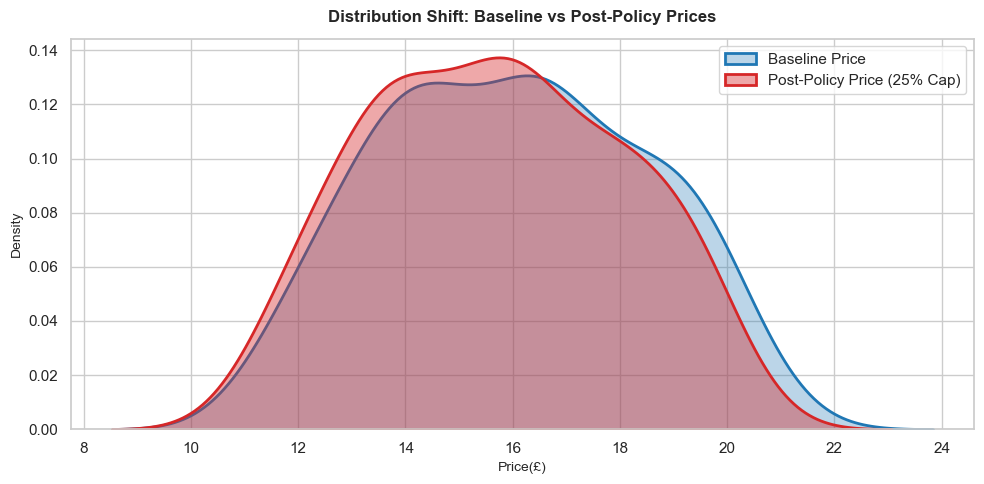

In [15]:
#Figure 1: Price distibution pre and post-policy
#Building overlapping distribution plot
plt.figure(figsize=(10,5))

#Plotting baseline price distribution
sns.kdeplot(
    data=df_sim,
    x="baseline_price",
    label="Baseline Price",
    color="#1f77b4",
    fill=True,
    alpha=0.3,
    linewidth=2
)

#Plotting post-policy price distribution
sns.kdeplot(
    data=df_sim,
    x="policy_price",
    label="Post-Policy Price (25% Cap)",
    color="#d62728",
    fill=True,
    alpha=0.4,
    linewidth=2
)

#Label and title format
plt.title("Distribution Shift: Baseline vs Post-Policy Prices", fontsize =12, fontweight="bold", pad=12)
plt.xlabel("Price(£)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()

plt.show()
        


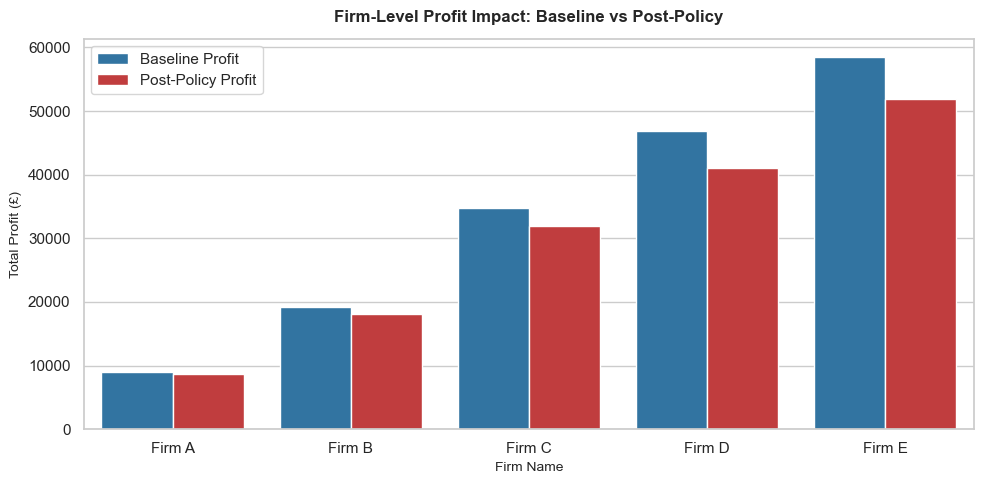

In [16]:
#Figure 2: Firm-Level Profit Impact
#Aggregate Profi by Firm
firm_profit =df_sim.groupby("firm_id")[["baseline_profit", "policy_profit"]].sum().reset_index()

#Reshape data for Seaborn 
firm_profit_melted = firm_profit.melt(
    id_vars="firm_id",
    value_vars=["baseline_profit", "policy_profit"],
    var_name="Scenario",
    value_name="Profit"
)

#Clean labels
firm_profit_melted["Scenario"] = firm_profit_melted["Scenario"].map({
    "baseline_profit": "Baseline Profit",
    "policy_profit": "Post-Policy Profit"
})

#Build Grouped Bar Chart
plt.figure(figsize=(10,5))
sns.barplot(
    data=firm_profit_melted,
    x="firm_id",
    y="Profit",
    hue="Scenario",
    palette=["#1f77b4","#d62728"]
)

plt.title("Firm-Level Profit Impact: Baseline vs Post-Policy", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Firm Name", fontsize=10)
plt.ylabel("Total Profit (£)", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()

plt.show()

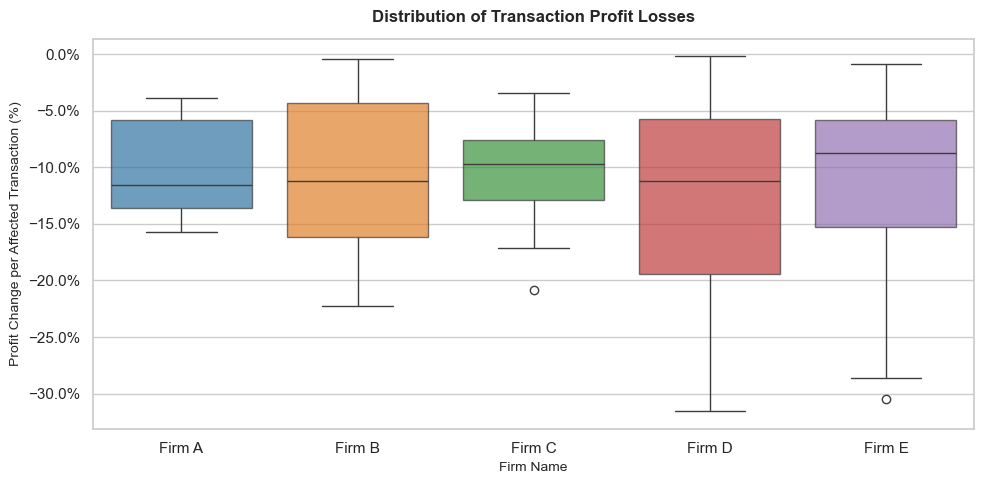

In [17]:
#Figure 3: A boxplot showing Percentage Profit Impact per firm
import matplotlib.ticker as mtick


#Calculating percentage change in profit for each transaction
df_sim["pct_change_profit"] = (df_sim["policy_profit"] - df_sim["baseline_profit"]) / df_sim["baseline_profit"]

plt.figure(figsize=(10,5))

#Scatter Plot to show price change vs volume change  (%)
sns.boxplot(
    data=df_sim[df_sim["pct_change_price"] < 0],
    x="firm_id",
    y="pct_change_profit",
    hue="firm_id",
    legend=False,
    palette="tab10",
    boxprops=dict(alpha=0.7)
)

#Format y axis as %
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("Distribution of Transaction Profit Losses", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Firm Name", fontsize=10)
plt.ylabel("Profit Change per Affected Transaction (%)", fontsize=10)
plt.tight_layout()

plt.show()

In [18]:
#Exporting Figures for PowerBI
import os
import matplotlib.ticker as mtick

# Creating folder for Outputs
os.makedirs("outputs", exist_ok=True)

# 2. Export CSV for Power BI
df_sim.to_csv("outputs/simulated_transactions.csv", index=False)
print("Saved 'outputs/simulated_transactions.csv' for Power BI.")

#Exporting Figure 1
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_sim, x="baseline_price", label="Baseline Price", color="#1f77b4", fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(data=df_sim, x="policy_price", label="Post-Policy Price (25% Cap)", color="#d62728", fill=True, alpha=0.4, linewidth=2)
plt.title("Distribution Shift: Baseline vs Post-Policy Prices", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Price (£)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.savefig("outputs/01_price_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# Exporting Figure 2
plt.figure(figsize=(10, 5))
sns.barplot(
    data=firm_profit_melted, 
    x="firm_id", 
    y="Profit", 
    hue="Scenario", 
    palette=["#1f77b4", "#d62728"]
)
plt.title("Firm-Level Profit Impact: Baseline vs Post-Policy", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Firm Name", fontsize=10)
plt.ylabel("Total Profit (£)", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("outputs/02_firm_profit_grouped_bar.png", dpi=300, bbox_inches="tight")
plt.close()

#Exporting Figure 3
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_sim[df_sim["pct_change_price"] < 0],
    x="firm_id",
    y="pct_change_profit",
    hue="firm_id",
    legend=False,
    palette="tab10",
    boxprops=dict(alpha=0.7)
)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title("Distribution of Transaction Profit Losses", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Firm Name", fontsize=10)
plt.ylabel("Profit Change per Affected Transaction (%)", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/03_firm_profit_boxplot.png", dpi=300, bbox_inches="tight")
plt.close()

print("All 3 high-resolution charts and CSV successfully exported to 'outputs/'")

Saved 'outputs/simulated_transactions.csv' for Power BI.
All 3 high-resolution charts and CSV successfully exported to 'outputs/'
